<a href="https://colab.research.google.com/github/voronv27/projects-in-ai-and-ml/blob/main/HW2/Homework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Decision Tree Classifier

Implementing a Decision Tree Classifier for my classification problem.

The data I used for homework 1 (and will again be using here) is this [Spotify Analysis Dataset 2025](https://www.kaggle.com/datasets/nabihazahid/spotify-dataset-for-churn-analysis). This dataset shows information about Spotify users and whether they churned or remained active on Spotify (0=active, 1=churned).

 To implement the Decision Tree Classifier, I used the built-in DecisionTreeClassifier from the sklearn package.

In [12]:
import pandas as pd

path = 'spotify.csv'

data = pd.read_csv(path)
data.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# separate features (x) from label (y)
label_col = "is_churned"
assert label_col in data.columns, f"Label column {label_col} not in data"

x = data.drop(columns=[label_col])
y = data[label_col]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Same preprocessing as in HW1 (with fix of preprocessing post-split)
num_cols = [c for c in x_train.columns if x_train[c].dtype != 'object']
cat_cols = [c for c in x_train.columns if x_train[c].dtype == 'object']

numeric_tf = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_tf = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop='first', sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, num_cols),
        ("cat", categorical_tf, cat_cols)
    ]
)

In [14]:
model1 = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", DecisionTreeClassifier())
])

model1.fit(x_train, y_train)

model2 = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", DecisionTreeClassifier(max_depth=5))
])

model2.fit(x_train, y_train)

model3 = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", DecisionTreeClassifier(max_depth=10))
])

model3.fit(x_train, y_train)

model4 = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", DecisionTreeClassifier(max_depth=10, min_samples_split=10))
])

model4.fit(x_train, y_train)

model5 = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", DecisionTreeClassifier(max_depth=10, max_features=3))
])

model5.fit(x_train, y_train)








Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['user_id', 'age',
                                                   'listening_time',
                                                   'songs_played_per_day',
                                                   'skip_rate',
                                                   'ads_listened_per_week',
                                                   'offline_listening']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'country',
                                                   'subscription_type',
                                                   'device_type'])])),
                ('clf', DecisionTreeClassifier(max_depth=10, max_features=3))])

In [15]:
from sklearn.metrics import accuracy_score, f1_score

y_pred = model1.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"First model accuracy score: {accuracy:.3f}")

f1 = f1_score(y_test, y_pred)
print(f"First model F1 score: {f1:.3}")

y_pred = model2.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Second model accuracy score: {accuracy:.3f}")

f1 = f1_score(y_test, y_pred)
print(f"Second model F1 score: {f1:.3}")

y_pred = model3.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Third model accuracy score: {accuracy:.3f}")

f1 = f1_score(y_test, y_pred)
print(f"Third model F1 score: {f1:.3}")

y_pred = model4.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Fourth model accuracy score: {accuracy:.3f}")

f1 = f1_score(y_test, y_pred)
print(f"Fourth model F1 score: {f1:.3}")

y_pred = model5.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Fifth model accuracy score: {accuracy:.3f}")

f1 = f1_score(y_test, y_pred)
print(f"Fifth model F1 score: {f1:.3}")

First model accuracy score: 0.619
First model F1 score: 0.267
Second model accuracy score: 0.745
Second model F1 score: 0.00971
Third model accuracy score: 0.720
Third model F1 score: 0.0931
Fourth model accuracy score: 0.714
Fourth model F1 score: 0.0729
Fifth model accuracy score: 0.721
Fifth model F1 score: 0.0551


Visualizing the trees:





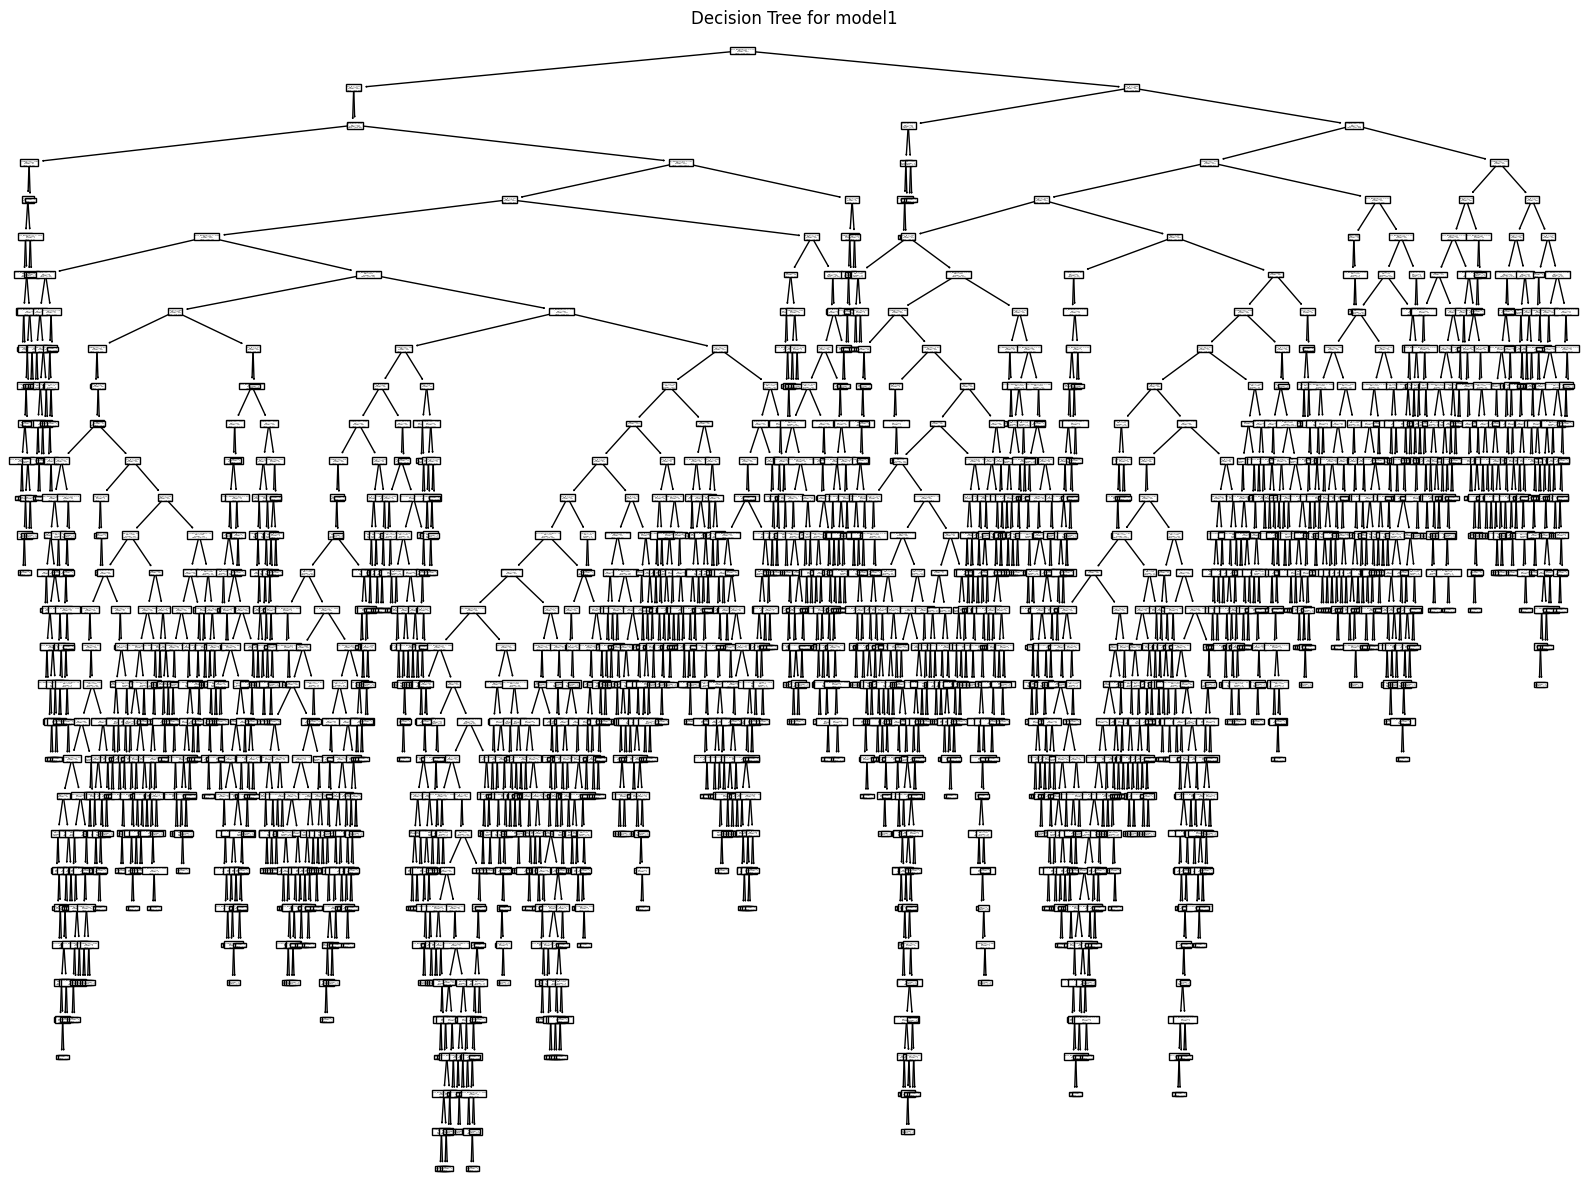

In [16]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = num_cols
preprocess.fit(x_train)
encoded_feature_names = preprocess.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols)
feature_names = feature_names + list(encoded_feature_names)

plt.figure(figsize=(20, 15))
plot_tree(model1.named_steps['clf'], feature_names=feature_names)
plt.title("Decision Tree for model1")
plt.show()

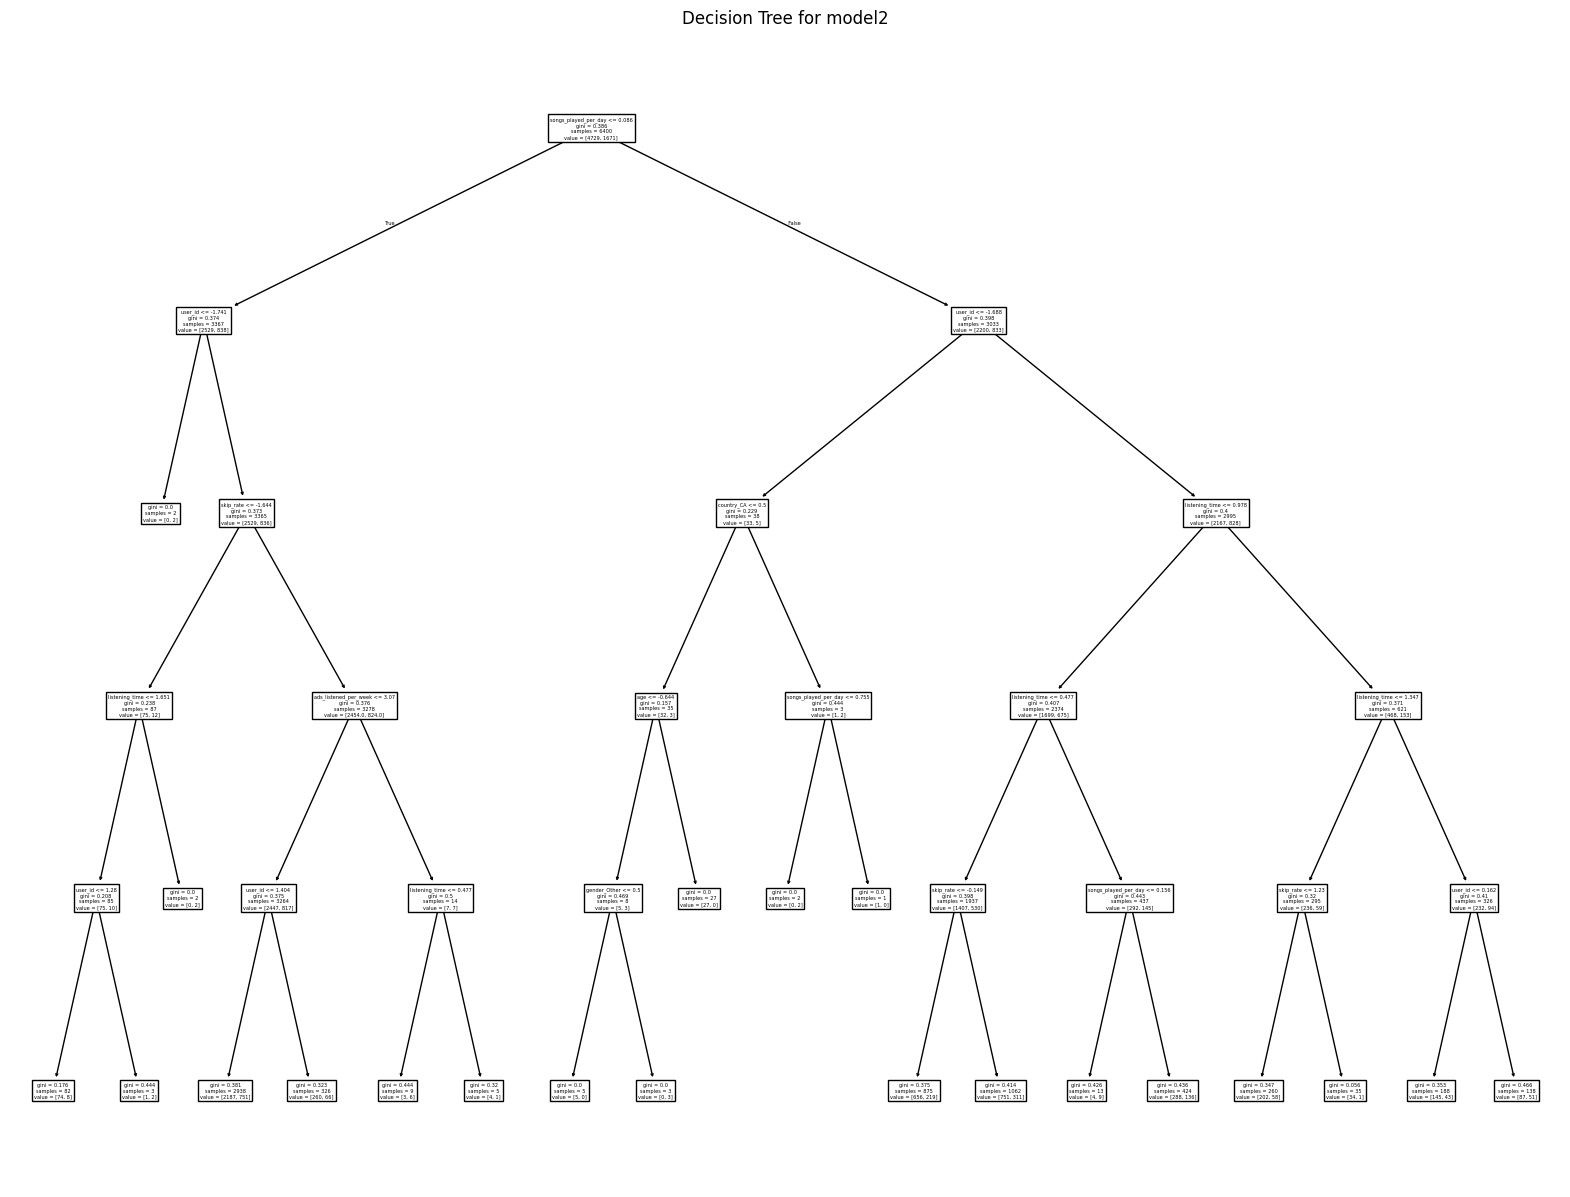

In [17]:
plt.figure(figsize=(20, 15))
plot_tree(model2.named_steps['clf'], feature_names=feature_names)
plt.title("Decision Tree for model2")
plt.show()

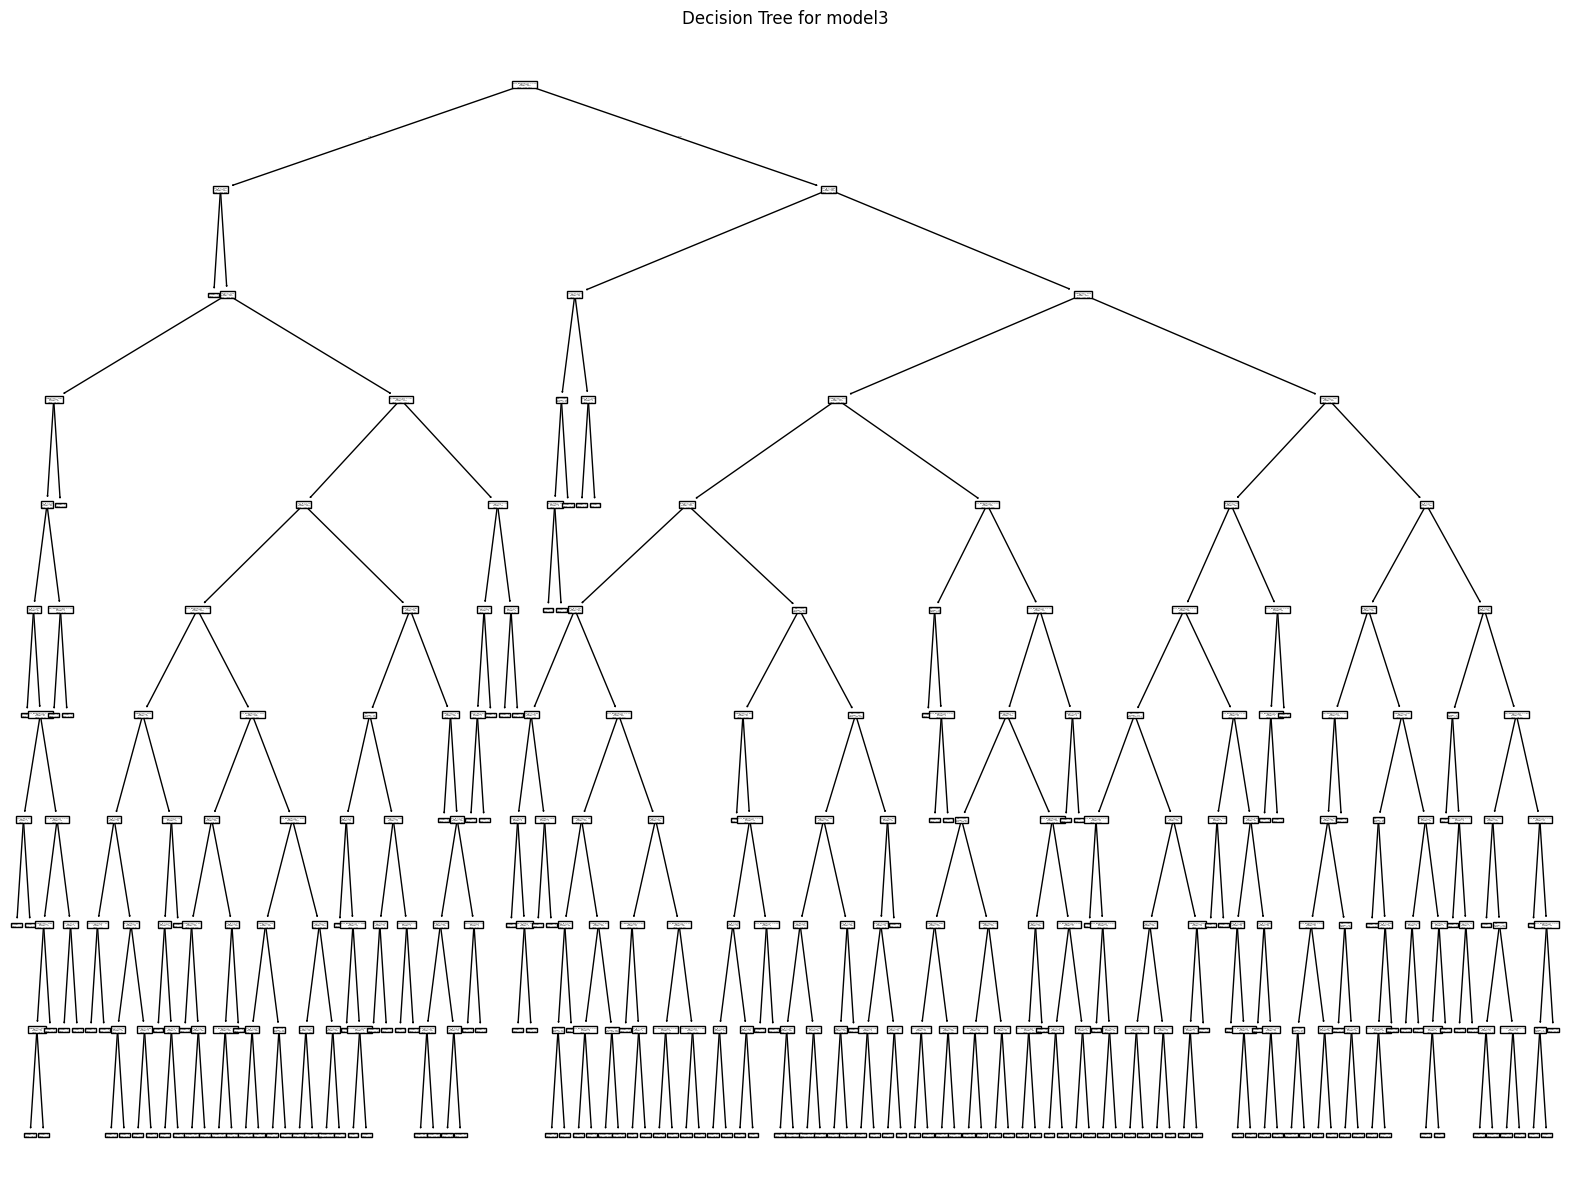

In [18]:
plt.figure(figsize=(20, 15))
plot_tree(model3.named_steps['clf'], feature_names=feature_names)
plt.title("Decision Tree for model3")
plt.show()

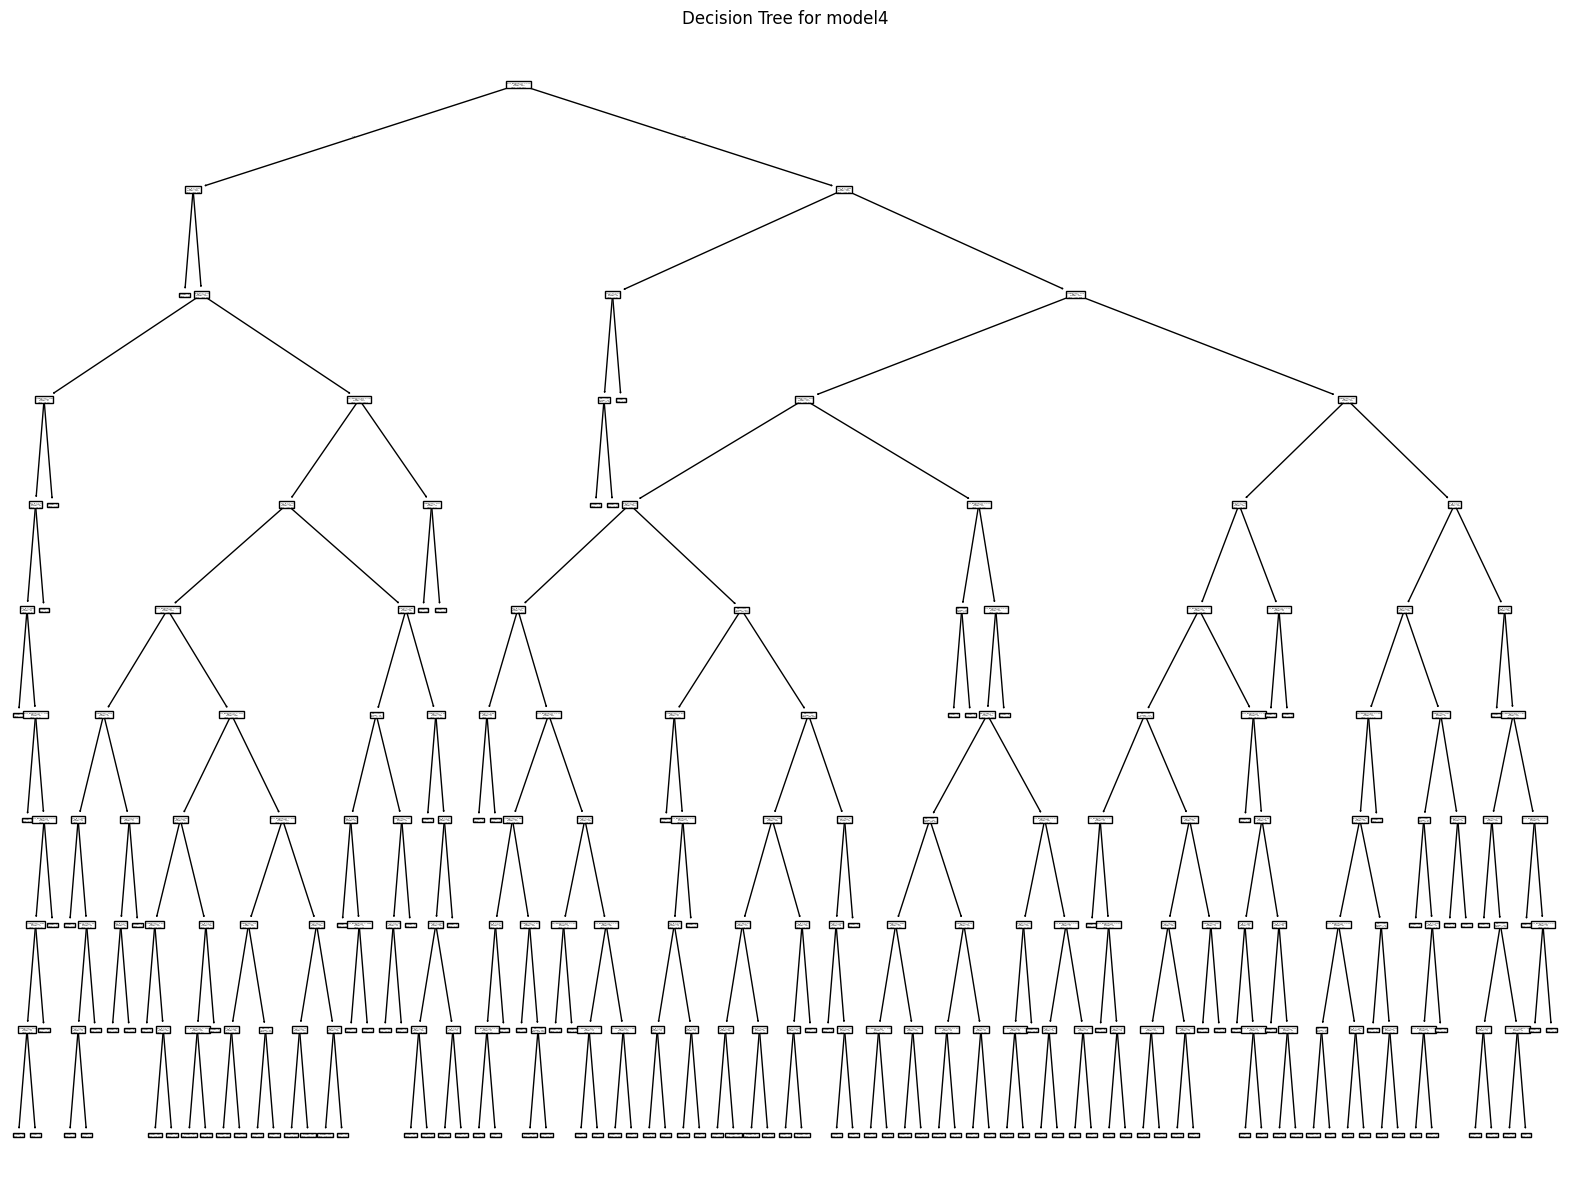

In [19]:
plt.figure(figsize=(20, 15))
plot_tree(model4.named_steps['clf'], feature_names=feature_names)
plt.title("Decision Tree for model4")
plt.show()

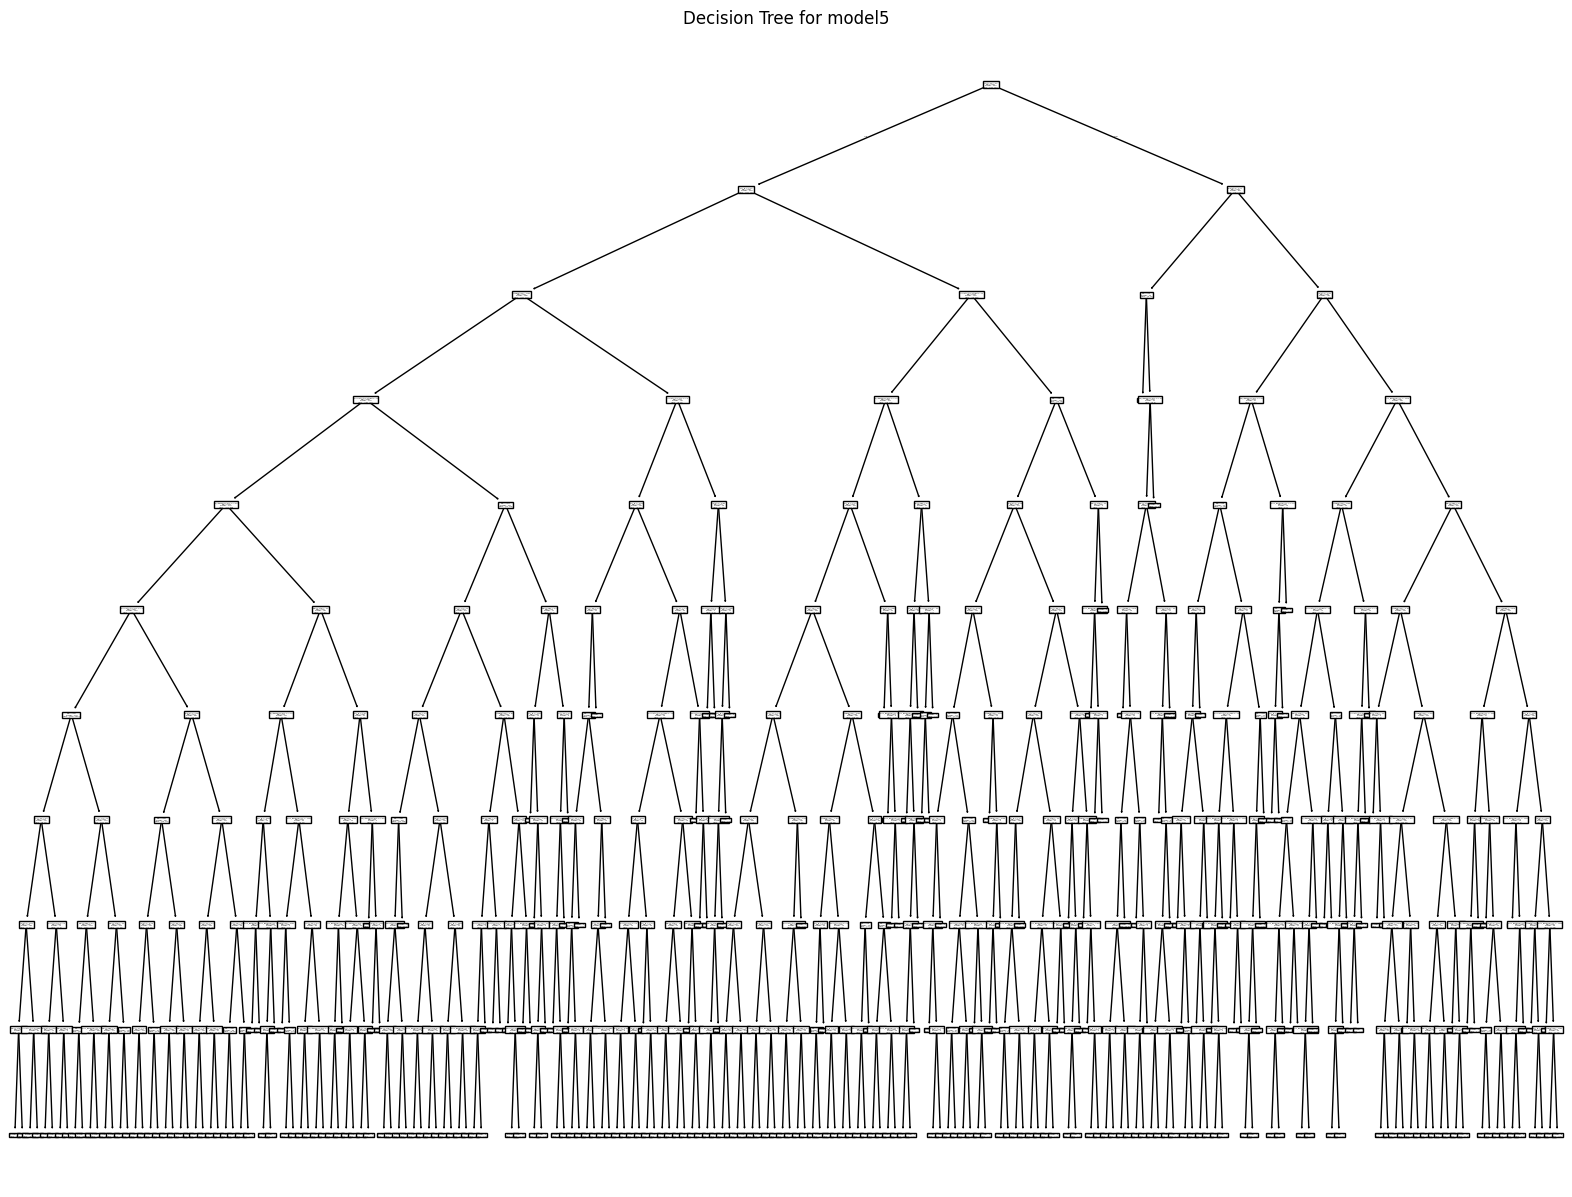

In [20]:
plt.figure(figsize=(20, 15))
plot_tree(model5.named_steps['clf'], feature_names=feature_names)
plt.title("Decision Tree for model5")
plt.show()

Initial Analysis:  

When the max_depth is unbounded, the tree gets a lot more branches. Changing min_samples_split in the fourth tree appears to have slightly simplified it but the change in structure isn't very noticeable (compared to tree 3, with the same depth but no change to min_samples_split), while changing max_features interestingly results in the tree splitting "the opposite way" from all the other trees (as in, more values are sent to the right side than left side in the first branch), and ending up with more branches (becomes more complex).

A deeper tree has the potential to be more complex since there's more areas for the branches to split. And being able to split on less combined features also results in more splits which makes the tree more complex as well. If min_samples_split was set to a higher value, it would probably have more of an impact in reducing tree complexity, since certain splits would no longer be allowed for separating a small batch of users. Adjusting this parameter could help prevent overfitting.

Sensitivity Analysis:  

Sensitivity analysis is a technique to determine how changes in one input parameter affects output, to find the variables with the most influence on the output. There are many different types of sensitivity analysis, but for this example, we will use local sensitivity analysis to look at how small changes to a parameter influence the model.

The two parameters we will examine are ads_listened_per_week and songs_played_per_day. We will do this analysis on model3, which is less complex than the unbounded depth model1 (which is probably overfitted), as in model1, I couldn't find datapoints on the decision boundary (i.e. with a ~0.5 probability of being in churned/active). Model3 isn't as overfitted and so has points with a ~0.5 probability that can be used for sensitivity analysis. I chose model3 out of the other bounded models (model2 through model5) as it had high accuracy and one of the higher f1 scores compared to the other models.



Citations  

[1](https://www.quadratichq.com/blog/what-is-sensitivity-analysis-evaluating-risk-and-uncertainty)
[2](https://www.ncbi.nlm.nih.gov/books/NBK126178/)

In [30]:
import numpy as np

# get a datapoint that's on the decision boundary
probs = model3.predict_proba(x_test)[:, 1]
i = np.argmin(np.abs(probs - 0.5))
x0 = x_test.iloc[i].copy()

# print probabilities to see that this point has a 50% chance of being churned/active
print(model3.predict_proba(x0.to_frame().T))


[[0.5 0.5]]


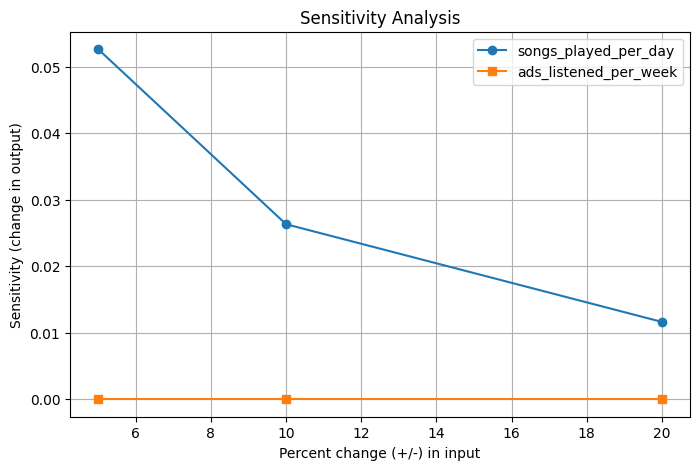

In [69]:
import matplotlib.pyplot as plt

def local_sensitivity(model, x0, feature, eps):
    x_plus = x0.copy()
    x_minus = x0.copy()

    # change feature value by eps in pos/neg direction
    x_plus[feature] += eps
    x_minus[feature] -= eps

    p_plus = model.predict_proba(x_plus.to_frame().T)[0, 1]
    p_minus = model.predict_proba(x_minus.to_frame().T)[0, 1]

    return abs(p_plus - p_minus) / (2 * eps)

songs_sensitivities = []
for percent in [0.05, 0.1, 0.2]:
  # get an epsilon scaled to the data
  eps = percent * x0["songs_played_per_day"]
  songs_sensitivity = local_sensitivity(model3, x0, "songs_played_per_day", eps)
  songs_sensitivities.append(songs_sensitivity)

ads_sensitivities = []
for percent in [0.05, 0.1, 0.2]:
  # our x0 could have 0 ads, so instead we find the mean of nonzero ads
  # to scale our percent by
  nonzero_ads = x_test[x_test["ads_listened_per_week"] > 0]
  eps = percent * nonzero_ads["ads_listened_per_week"].mean()
  ads_sensitivity = local_sensitivity(model3, x0, "ads_listened_per_week", eps)
  ads_sensitivities.append(ads_sensitivity)

plt.figure(figsize=(8,5))
plt.plot([5, 10, 20], songs_sensitivities, marker='o', label='songs_played_per_day')
plt.plot([5, 10, 20], ads_sensitivities, marker='s', label='ads_listened_per_week')
plt.xlabel('Percent change (+/-) in input')
plt.ylabel('Sensitivity (change in output)')
plt.title('Sensitivity Analysis')
plt.legend()
plt.grid(True)
plt.show()


As seen above, a 5% change in input results in a probability change of around 0.055, with this sensitivity decreasing as we introduce greater percent changes to the input. Meanwhile, changing the number of ads listened to per week for the data point seems to have had no effect on its probability--so the model does not consider this an important deciding factor (most likely, it looks at subscription type instead).

#Task 2: Bagging & Boosting

I choose to use the Random Forest method for my bagging method, and the XGBoost algorithm for my boosting method.

Random Forest:

In [71]:
from sklearn.ensemble import RandomForestClassifier

# we have 100 trees
model_rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        n_jobs=-1
    ))
])

model_rf.fit(x_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['user_id', 'age',
                                                   'listening_time',
                                                   'songs_played_per_day',
                                                   'skip_rate',
                                                   'ads_listened_per_week',
                                                   'offline_listening']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'country',
                                                   'subscription_type',
                                                   'device_type'])])),
                ('clf', RandomForestClassifier(n_jobs=-1))])

Stratified K-fold Cross-Validation  

We will evaluate the model with 5, 10, and 15 folds.

In [77]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score

# evaluate the model
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
n_scores = cross_val_score(model_rf, x, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')

# report performance
print('Accuracy (5 folds): %.3f (%.3f)' % (np.mean(n_scores), np.std(n_scores)))

# evaluate the model
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(model_rf, x, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')

# report performance
print('Accuracy (10 folds): %.3f (%.3f)' % (np.mean(n_scores), np.std(n_scores)))

# evaluate the model
cv = RepeatedStratifiedKFold(n_splits=15, n_repeats=3, random_state=1)
n_scores = cross_val_score(model_rf, x, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')

# report performance
print('Accuracy (15 folds): %.3f (%.3f)' % (np.mean(n_scores), np.std(n_scores)))

Accuracy (5 folds): 0.738 (0.001)
Accuracy (10 folds): 0.739 (0.002)
Accuracy (15 folds): 0.739 (0.003)


As the number of folds increases (i.e., we have more datapoints in the training and less in the testing pool), we see a slight increase in both accuracy and standard deviation. The model gets more data to train on with more folds so it can become more accurate, while less test points results in higher standard deviation for the ones that remain.

I evaluated the model's accuracy, precision, and f1-score.

In [81]:
from sklearn.metrics import precision_score
y_pred = model1.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"DCT model accuracy score: {accuracy:.3f}")

precision = precision_score(y_test, y_pred)
print(f"DCT model precision score: {precision:.3f}")

f1 = f1_score(y_test, y_pred)
print(f"DCT model F1 score: {f1:.3}")

y_pred = model_rf.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest model accuracy score: {accuracy:.3f}")

precision = precision_score(y_test, y_pred)
print(f"Random Forest model precision score: {precision:.3f}")

f1 = f1_score(y_test, y_pred)
print(f"Random Forest model F1 score: {f1:.3}")

DCT model accuracy score: 0.619
DCT model precision score: 0.257
DCT model F1 score: 0.267
Random Forest model accuracy score: 0.747
Random Forest model precision score: 0.333
Random Forest model F1 score: 0.0241


Compared to the "regular" decision tree classifier (model1 from task 1), the accuracy on this model is higher, but the f1-score is lower. The precision has improved however, meaning there are less false positives (and the lowered f1-score must be a result of a decrease in recall, or being able to predict true positive values). The data has a lot more 0 values for the is_churned category, so a method like Random Forest which aims to reduce variance in the model would probably just tend to predict 0 for more data points. As such, we end up with a higher accuracy, but lower f1-score.

Depending on what metric we prioritize, we can consider either model better/worse. Accuracy-wise, the random forest model is more likely to give you a correct result. However, the regular decision tree is more likely to give you a correct positive result. Someone performing an analysis on current Spotify users may just want a more accurate prediction of how many will keep using the app (random forest model). Meanwhile, someone on the Spotify marketing team who wants to contact users who may be considering leaving Spotify would probably prefer the model that more accurately predicts positives (users who are leaving).

XGBoost:

In [82]:
from xgboost import XGBClassifier

# 100 boost rounds with max tree depth of 3 for each and
model_xgb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
    ))
])

model_xgb.fit(x_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['user_id', 'age',
                                                   'listening_time',
                                                   'songs_played_per_day',
                                                   'skip_rate',
                                                   'ads_listened_per_week',
                                                   'offline_listening']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'country',
                                                   'subscription_ty...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [84]:
# evaluate the model
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
n_scores = cross_val_score(model_xgb, x, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')

# report performance
print('Accuracy (5 folds): %.3f (%.3f)' % (np.mean(n_scores), np.std(n_scores)))

# evaluate the model
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(model_xgb, x, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')

# report performance
print('Accuracy (10 folds): %.3f (%.3f)' % (np.mean(n_scores), np.std(n_scores)))

# evaluate the model
cv = RepeatedStratifiedKFold(n_splits=15, n_repeats=3, random_state=1)
n_scores = cross_val_score(model_xgb, x, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')

# report performance
print('Accuracy (15 folds): %.3f (%.3f)' % (np.mean(n_scores), np.std(n_scores)))

Accuracy (5 folds): 0.740 (0.001)
Accuracy (10 folds): 0.741 (0.001)
Accuracy (15 folds): 0.741 (0.001)


As in the Random Forest model, we see a slight increase in accuracy as the number of folds increases. There isn't any notable change in the standard deviation this time though.

Evaluating on 3 metrics:

In [86]:
from sklearn.metrics import recall_score
y_pred = model_xgb.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost model accuracy score: {accuracy:.3f}")

precision = precision_score(y_test, y_pred)
print(f"XGBoost model precision score: {precision:.3f}")

recall = recall_score(y_test, y_pred)
print(f"XGBoost model recall score: {recall:.3f}")

f1 = f1_score(y_test, y_pred)
print(f"XGBoost model F1 score: {f1:.3}")

XGBoost model accuracy score: 0.748
XGBoost model precision score: 0.000
XGBoost model recall score: 0.000
XGBoost model F1 score: 0.0


Seeing that this model's f1-score was 0, I decided to also show recall score for this model, even though the 3 metrics I chose were accuracy, precision, and f1-score.

From these results, we can see that the model is mainly predicting everything as negative (0) (though not absolutely everything is predicted as 0, since we don't get an error when calculating the f1-score--the value is just so small that it's getting rounded to 0 in the print output). This does slightly improve accuracy for the dataset, but I'd argue that this model is much worse than the other two models since it can't correctly predict a single positive value. Looking at metrics other than accuracy shows how unreliable this model truly is.

# Task 3: Comparing Models

Confusion Matrix

Confusion matrix for test fold 5:

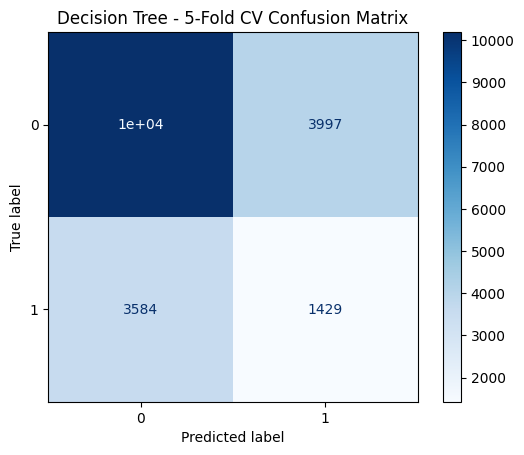

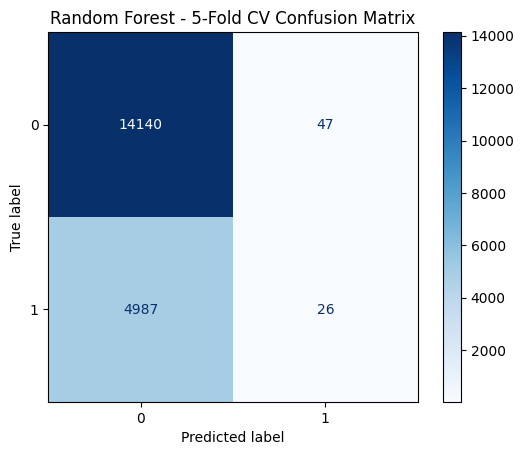

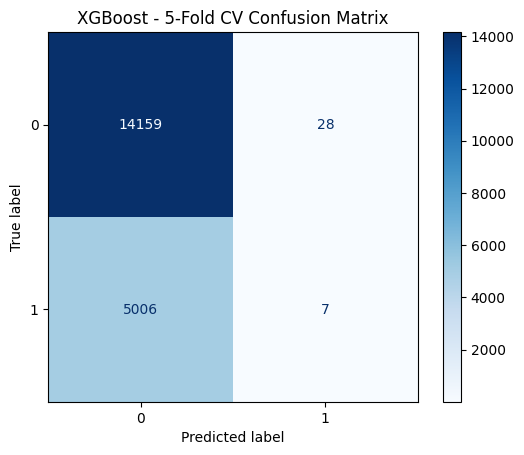

In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

models = {
    "Decision Tree": model1,
    "Random Forest": model_rf,
    "XGBoost": model_xgb
}

kf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)

# store true labels and predicted labels per model
y_true_all = []
y_pred_all = {name: [] for name in models.keys()}

# used later for paired t-test
f1_scores = {name: [] for name in models.keys()}

# iterate through the fold's train/test
for train_index, test_index in kf.split(x_train, y_train):
    x_train_fold, x_test_fold = x_train.iloc[train_index], x_train.iloc[test_index]
    y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    y_true_all.extend(y_test_fold)  # same for all models

    # predict y for each model and store in y_pred_all
    for name, model in models.items():
        model.fit(x_train_fold, y_train_fold)
        y_pred_fold = model.predict(x_test_fold)
        y_pred_all[name].extend(y_pred_fold)
        f1_scores[name].append(f1_score(y_test_fold, y_pred_fold))

# confusion matrix for each model
for name in models.keys():
    cm = confusion_matrix(y_true_all, y_pred_all[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{name} - 5-Fold CV Confusion Matrix")
    plt.show()


We can see that the models are all really good at predicting true negatives. The regular decision tree has more false positives, but less false negatives than the other two models, and it also correctly predicts a lot more true positives. The Random Forest and XGBoost models predict almost no true positives and predict more false negatives, but they also predict almost no false positives.

Essentially, the decision tree classifier predicts more positives which makes it better at predicting true positives (but more likely to predict false positives). The other two trees predict less positives which makes them better at avoiding false positives, but gain more false negatives as a result.

Statistical test to determine if models are different:  

We will compare f1-scores with a paired t-test.

In [99]:
from scipy.stats import ttest_rel

# Compare Decision Tree vs Random Forest
t_stat, p_value = ttest_rel(f1_scores["Decision Tree"], f1_scores["Random Forest"])
print(f"DT vs RF: t={t_stat:.4f}, p={p_value:.4f}")

# Compare Decision Tree vs XGBoost
t_stat, p_value = ttest_rel(f1_scores["Decision Tree"], f1_scores["XGBoost"])
print(f"DT vs XGB: t={t_stat:.4f}, p={p_value:.4f}")

# Compare Random Forest vs XGBoost
t_stat, p_value = ttest_rel(f1_scores["Random Forest"], f1_scores["XGBoost"])
print(f"RF vs XGB: t={t_stat:.4f}, p={p_value:.4f}")


DT vs RF: t=49.5923, p=0.0000
DT vs XGB: t=41.1184, p=0.0000
RF vs XGB: t=2.7293, p=0.0163


The t value represents the difference in accuracy between the two models that are being compared, while the p value represents whether this difference is statistically significant ($p \ge 0.5$ meaning no statistical difference). The p-value for all of these is below 0.05, so there is a statistically significant difference between all of these models. In particular, there is a very clear difference between the decision tree classifier and the other two models.

We can see from these numbers that the f1-score is significantly different for all 3 models, and that it is higher for the Decision Tree model than Random Forest and XGBoost, and higher for the Random Forest model than XGBoost. The t-value itself is the number of standard deviations (on average) that the f1-score from the first model will be from the second. It would be very statistically unlikely for the Decision Tree's f1-score to be 49 standard deviations away from the Random Forest f1-score while the models themselves have no significant difference, hence why the p-value is 0 to show that there is a signficant diffence between the two models.

Note: I decided to use f1-score as opposed to accuracy for this comparison since I have an unbalanced dataset and f1-score tells more about false positives and negatives.

Bias vs Variance Tradeoff:  

In machine learning, high bias represents underfitting, where the model makes incorrect assumptions about the data, while high variance represents overfitting, where the model is overly sensitive and fits itself to the noise in the data instead of just the meaningful patterns. The Decision Tree model created in task 1 (specifically model1, where max_depth was not set) has a higher variance--it is a more complex model. The Random Forest and XGBoost models have a higher bias and lower variance than the Decision Tree model, they make more general assumptions and group more data points into the negative category as that is the general pattern of the dataset.

As a result of their lower variance, the RF and XGB models have a higher accuracy because they are less affected by the noise in the data (however they also have a lower f1-score as they have more incorrect generalizations when it comes to false negatives and true positives--a greater bias). For the Decision Tree in task 1, comparing different max depths for the tree changed the accuracy and f1-scores as well, a less complex tree was no longer overfitted (or could even be underfitted) leading to better accuracy (though the f1-score was worse).

The overall goal is to find a model that minimizes bias and variance together (minimizes error). The ideal model takes into account the data well enough to find all significant patterns, but doesn't overfit to the "fake" patterns it may find in the noise of the data. Methods like Random Forest and XGBoost help with this since they aggregate multiple underfit models together, preventing overfitting. This is why these models showed higher accuracy than the Decision Tree model, since they combined many trees, they were able to look at the true patterns in the data.

# Graduate Level Task: Hyperparameter Tuning

We will tune these hyperparameters of XGBoost using random search: learning rate, max depth, and subsample.

In [105]:
from sklearn.metrics import log_loss
learning_rates = [0.5, 0.1, 0.01, 0.001]
max_depths = [2, 3, 4, 5, 6]
subsamples = [0.25, 0.5, 0.75, 1]
results = []

for i in range(25):
  # randomly pick parameters
  lr = np.random.choice(learning_rates)
  md = np.random.choice(max_depths)
  sub = np.random.choice(subsamples)

  model_xgb = Pipeline(steps=[
      ("preprocess", preprocess),
      ("clf", XGBClassifier(
      n_estimators=100,
      max_depth=md,
      learning_rate=lr,
      subsample=sub
      ))
  ])
  model_xgb.fit(x_train, y_train)

  y_pred = model_xgb.predict(x_test)
  y_prob = model_xgb.predict_proba(x_test)

  loss = log_loss(y_test, y_prob)
  acc = accuracy_score(y_test, y_pred)
  results.append({
        "learning_rate": lr,
        "max_depth": md,
        "subsample": sub,
        "loss": loss,
        "accuracy": acc
    })
  print(f"learning rate: {lr}, max depth: {md}, subsample: {sub}, loss: {loss}, accuracy: {acc}")

best_params = min(results, key=lambda x: x['loss'])
lr, md, sub, loss, acc = best_params["learning_rate"], best_params["max_depth"], best_params["subsample"], best_params["loss"], best_params["accuracy"]
print()
print(f"Best parameters: learning rate: {lr}, max depth: {md}, subsample: {sub}, loss: {loss}, accuracy: {acc}")


learning rate: 0.1, max depth: 5, subsample: 0.25, loss: 0.5888588359848671, accuracy: 0.739375
learning rate: 0.001, max depth: 4, subsample: 0.5, loss: 0.5625673444125608, accuracy: 0.75
learning rate: 0.01, max depth: 5, subsample: 1.0, loss: 0.5636860208266983, accuracy: 0.75
learning rate: 0.1, max depth: 5, subsample: 0.75, loss: 0.5738202888127851, accuracy: 0.74125
learning rate: 0.001, max depth: 4, subsample: 0.75, loss: 0.5626003095596779, accuracy: 0.75
learning rate: 0.5, max depth: 5, subsample: 0.25, loss: 0.9365387228861186, accuracy: 0.65
learning rate: 0.01, max depth: 2, subsample: 1.0, loss: 0.5631124019795893, accuracy: 0.75
learning rate: 0.1, max depth: 3, subsample: 0.5, loss: 0.5669080354948666, accuracy: 0.75
learning rate: 0.1, max depth: 6, subsample: 0.25, loss: 0.5921195722394301, accuracy: 0.735
learning rate: 0.001, max depth: 3, subsample: 0.5, loss: 0.5626187226427853, accuracy: 0.75
learning rate: 0.5, max depth: 5, subsample: 0.5, loss: 0.76937823659

Hyperparameter Sensitivity Analysis  

Here we show the sensitivity of the model to changes to these hyperparameters. We do this by fixing all but one hyperparameter and seeing how changing this hyperparameter changes the model's accuracy and f1-score. I fixed the other two hyperparameters at the "best" value as found above, and changed the non-fixed hyperparameter by a percentage to measure sensitivity.

In [120]:
# Change learning rate only
results_lr = []
for percent in [0.1, 0.2, 0.5]:
  lr_plus = 0.01 * (1 + percent)
  model_xgb = Pipeline(steps=[
      ("preprocess", preprocess),
      ("clf", XGBClassifier(
      n_estimators=100,
      max_depth=4,
      learning_rate=lr_plus,
      subsample=0.5
      ))
  ])
  model_xgb.fit(x_train, y_train)

  y_pred = model_xgb.predict(x_test)
  y_prob = model_xgb.predict_proba(x_test)

  loss_plus = log_loss(y_test, y_prob)
  acc_plus = accuracy_score(y_test, y_pred)

  lr_minus = 0.01 * (1 - percent)
  model_xgb = Pipeline(steps=[
      ("preprocess", preprocess),
      ("clf", XGBClassifier(
      n_estimators=100,
      max_depth=4,
      learning_rate=lr_minus,
      subsample=0.5
      ))
  ])
  model_xgb.fit(x_train, y_train)

  y_pred = model_xgb.predict(x_test)
  y_prob = model_xgb.predict_proba(x_test)

  loss_minus = log_loss(y_test, y_prob)
  acc_minus = accuracy_score(y_test, y_pred)

  loss_sensitivity = (loss_plus - loss_minus) / (lr_plus - lr_minus)
  acc_sensitivity = (acc_plus - acc_minus) / (lr_plus - lr_minus)

  results_lr.append({
        "percent": percent,
        "loss_sensitivity": loss_sensitivity,
        "accuracy_sensitivity": acc_sensitivity
    })

# Change max depth only
results_md = []
for change in [1, 2]:
  md_plus = 4 + change
  model_xgb = Pipeline(steps=[
      ("preprocess", preprocess),
      ("clf", XGBClassifier(
      n_estimators=100,
      max_depth=md_plus,
      learning_rate=0.01,
      subsample=0.5
      ))
  ])
  model_xgb.fit(x_train, y_train)

  y_pred = model_xgb.predict(x_test)
  y_prob = model_xgb.predict_proba(x_test)

  loss_plus = log_loss(y_test, y_prob)
  acc_plus = accuracy_score(y_test, y_pred)

  md_minus = 4 - change
  model_xgb = Pipeline(steps=[
      ("preprocess", preprocess),
      ("clf", XGBClassifier(
      n_estimators=100,
      max_depth=md_minus,
      learning_rate=0.01,
      subsample=0.5
      ))
  ])
  model_xgb.fit(x_train, y_train)

  y_pred = model_xgb.predict(x_test)
  y_prob = model_xgb.predict_proba(x_test)

  loss_minus = log_loss(y_test, y_prob)
  acc_minus = accuracy_score(y_test, y_pred)

  loss_sensitivity = (loss_plus - loss_minus) / (md_plus - md_minus)
  acc_sensitivity = (acc_plus - acc_minus) / (md_plus - md_minus)

  results_md.append({
        "change": change,
        "loss_sensitivity": loss_sensitivity,
        "accuracy_sensitivity": acc_sensitivity
    })

# Change subsample only
results_sub = []
for percent in [0.1, 0.2, 0.5]:
  sub_plus = 0.5 * (1 + percent)
  model_xgb = Pipeline(steps=[
      ("preprocess", preprocess),
      ("clf", XGBClassifier(
      n_estimators=100,
      max_depth=4,
      learning_rate=0.01,
      subsample=sub_plus
      ))
  ])
  model_xgb.fit(x_train, y_train)

  y_pred = model_xgb.predict(x_test)
  y_prob = model_xgb.predict_proba(x_test)

  loss_plus = log_loss(y_test, y_prob)
  acc_plus = accuracy_score(y_test, y_pred)

  sub_minus = 0.5 * (1 - percent)
  model_xgb = Pipeline(steps=[
      ("preprocess", preprocess),
      ("clf", XGBClassifier(
      n_estimators=100,
      max_depth=4,
      learning_rate=0.01,
      subsample=sub_minus
      ))
  ])
  model_xgb.fit(x_train, y_train)

  y_pred = model_xgb.predict(x_test)
  y_prob = model_xgb.predict_proba(x_test)

  loss_minus = log_loss(y_test, y_prob)
  acc_minus = accuracy_score(y_test, y_pred)

  loss_sensitivity = (loss_plus - loss_minus) / (sub_plus - sub_minus)
  acc_sensitivity = (acc_plus - acc_minus) / (sub_plus - sub_minus)

  results_sub.append({
        "percent": percent,
        "loss_sensitivity": loss_sensitivity,
        "accuracy_sensitivity": acc_sensitivity
    })

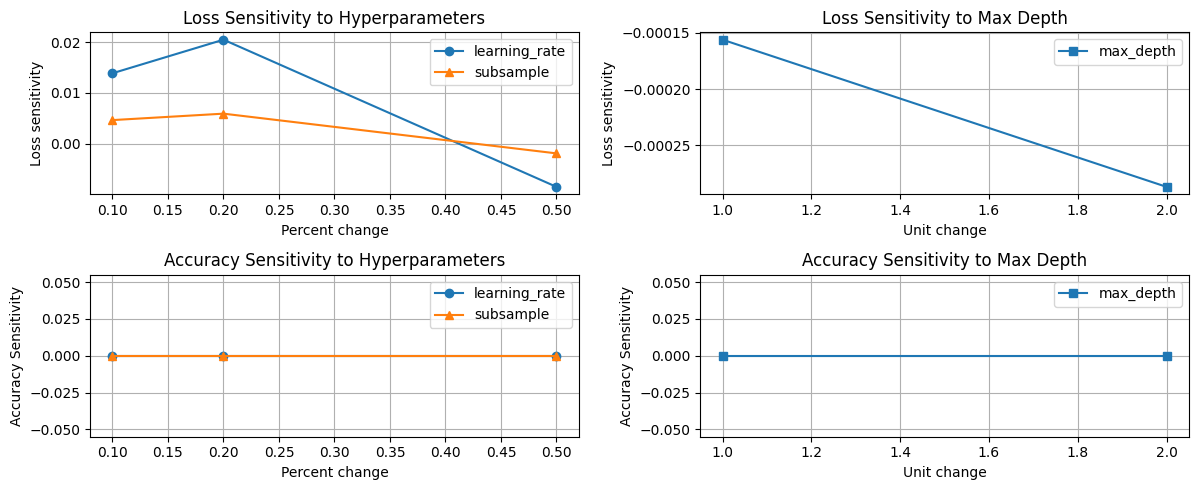

In [121]:
# Convert results to DataFrames
df_lr = pd.DataFrame(results_lr)
df_md = pd.DataFrame(results_md)
df_sub = pd.DataFrame(results_sub)

plt.figure(figsize=(12,5))

# loss
plt.subplot(2,2,1)
plt.plot(df_lr["percent"], df_lr["loss_sensitivity"], 'o-', label="learning_rate")
plt.plot(df_sub["percent"], df_sub["loss_sensitivity"], '^-', label="subsample")
plt.title("Loss Sensitivity to Hyperparameters")
plt.xlabel("Percent change")
plt.ylabel("Loss sensitivity")
plt.legend()
plt.grid(True)

plt.subplot(2,2,2)
plt.plot(df_md["change"], df_md["loss_sensitivity"], 's-', label="max_depth")
plt.title("Loss Sensitivity to Max Depth")
plt.xlabel("Unit change")
plt.ylabel("Loss sensitivity")
plt.legend()
plt.grid(True)


# accuracy
plt.subplot(2,2,3)
plt.plot(df_lr["percent"], df_lr["accuracy_sensitivity"], 'o-', label="learning_rate")
plt.plot(df_sub["percent"], df_sub["accuracy_sensitivity"], '^-', label="subsample")
plt.title("Accuracy Sensitivity to Hyperparameters")
plt.xlabel("Percent change")
plt.ylabel("Accuracy Sensitivity")
plt.legend()
plt.grid(True)

plt.subplot(2,2,4)
plt.plot(df_md["change"], df_md["accuracy_sensitivity"], 's-', label="max_depth")
plt.title("Accuracy Sensitivity to Max Depth")
plt.xlabel("Unit change")
plt.ylabel("Accuracy Sensitivity")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Since max_depth can only be changed by integer values, I plotted it separately from the other two hyperparameters.

As we can see from the results above, the model's accuracy seems to be barely (if at all, it may just be zeroed out or it may be very small) impacted by changing the hyperparameters, but the loss lets us see what changes the model is more sensitive to. Changes to the learning rate impact the model greatest, with sensitivity peaking at a 20% change to learning rate. That being said, the model doesn't seem that sensitive to any of the the hyperparameters changing. This is probably due to the way XGBoost creates a model from many smaller weak models. The smaller models are probably impacted a lot more by the change in hyperparameters, but the average result will end up changing less.

Changing the subsample size gives the smaller models less data, but when you have 100 of them, they will still find the patterns in the data and average out to around the same result. Similarly, changing the max depth to a smaller value means more underfit individual models but they will average to a model with better fit. The learning rate changes how much each individual model contributes to the overall model, which is probably why it had the greatest impact on sensitivity, since it affects how the overall model learns. However with enough smaller models, the larger model will average to around the same model for different learning rates, it will just do so at different speeds. In this example, the 100 models we create are probably enough that a change in learning rate doesn't impact the model too harshly.

It may also be that each "new" weak model being created is very similar to the other weak models, since we have a skewing in the data to is_churned=0 (which means an underfit model will just predict is_churned=0 for most cases). This also means that learning rate has less of an impact because the model overall is not changing as much.